In [ ]:
%pip install yfinance pandas numpy matplotlib seaborn scipy

In [7]:
# Import core data science and finance libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("crest")

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Define the explicit currency pairs
tickers = ['USDINR=X', 'EURINR=X', 'GBPINR=X']
start_date = '2022-01-01'
end_date = '2024-01-01'

# Fetch historical exchange rate data (using 'Close' instead of 'Adj Close')
print("Fetching FX Data...")
fx_data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Drop any missing data to ensure clean columns
fx_data = fx_data.dropna()

# Rename columns explicitly using a dictionary so it never mislabels or crashes
fx_data.rename(columns={
    'USDINR=X': 'USD_INR', 
    'EURINR=X': 'EUR_INR', 
    'GBPINR=X': 'GBP_INR'
}, inplace=True)

# Calculate daily logarithmic returns (standard financial data science practice)
returns = np.log(fx_data / fx_data.shift(1)).dropna()
print("\nFirst 5 rows of daily log returns:")
display(returns.head())

[                       0%                       ]

Fetching FX Data...


[*********************100%***********************]  3 of 3 completed


First 5 rows of daily log returns:


Ticker,EUR_INR,GBP_INR,USD_INR
Date,,,
2022-01-04,-0.007223,-0.004934,-0.001484
2022-01-05,0.000048,0.005262,0.001767
2022-01-06,-0.000833,0.000626,-0.001407
2022-01-07,-0.000119,-0.001877,-0.000145
2022-01-10,0.004469,0.001265,-0.002008


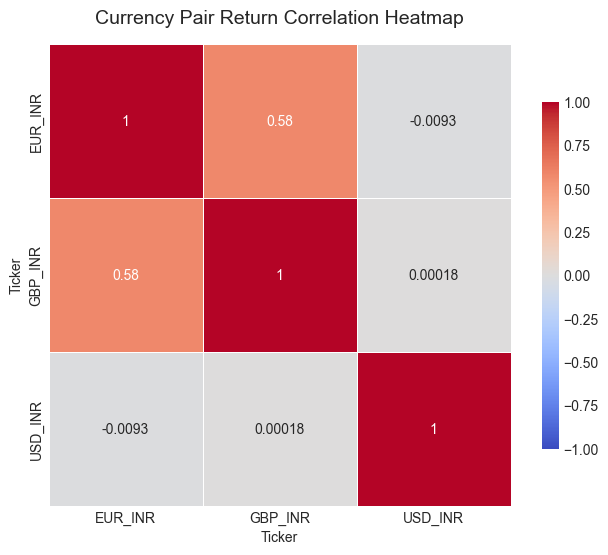

Annualized Volatility (Risk):
Ticker
EUR_INR    0.092762
GBP_INR    0.093666
USD_INR    0.051237
dtype: float64


In [10]:
# Plotting the FX Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = returns.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Currency Pair Return Correlation Heatmap', fontsize=14, pad=15)
plt.show()

# Calculate and display annualized volatility
annual_volatility = returns.std() * np.sqrt(252)
print("Annualized Volatility (Risk):")
print(annual_volatility)

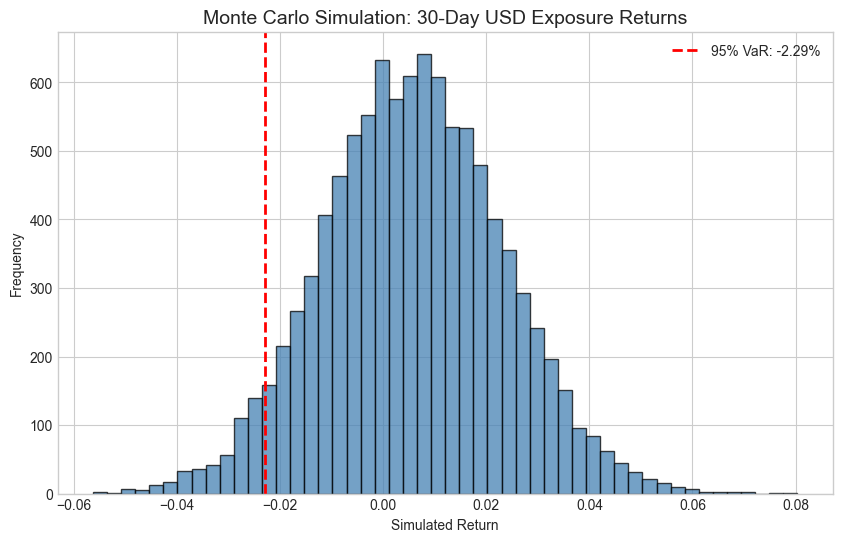

If the company holds $1,000,000 USD, there is a 5% probability that currency fluctuations will cause a loss exceeding $22,920.01 over the next 30 days.


In [11]:
# Define simulation parameters for USD/INR
np.random.seed(42)
num_simulations = 10000
time_horizon = 30 # 30-day risk forecast

# Calculate historical drift and variance for USD/INR
usd_mean = returns['USD_INR'].mean()
usd_var = returns['USD_INR'].var()
drift = usd_mean - (0.5 * usd_var)
usd_std = returns['USD_INR'].std()

# Generate 10,000 simulated 30-day return paths using geometric brownian motion
daily_returns = np.exp(drift + usd_std * norm.ppf(np.random.rand(time_horizon, num_simulations)))

# Assume a mock corporate exposure of 1,000,000 USD
initial_exposure = 1000000 
price_paths = np.zeros_like(daily_returns)
price_paths[0] = initial_exposure

for t in range(1, time_horizon):
    price_paths[t] = price_paths[t-1] * daily_returns[t]

# Extract the final simulated portfolio values
final_values = price_paths[-1]
portfolio_returns = (final_values - initial_exposure) / initial_exposure

# Calculate 95% Value at Risk (VaR)
confidence_level = 0.95
var_95 = np.percentile(portfolio_returns, 100 - (confidence_level * 100))

# Visualize the Monte Carlo Distribution
plt.figure(figsize=(10, 6))
plt.hist(portfolio_returns, bins=50, alpha=0.75, color='steelblue', edgecolor='black')
plt.axvline(var_95, color='red', linestyle='dashed', linewidth=2, 
            label=f'95% VaR: {var_95:.2%}')
plt.title('Monte Carlo Simulation: 30-Day USD Exposure Returns', fontsize=14)
plt.xlabel('Simulated Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"If the company holds $1,000,000 USD, there is a 5% probability that currency fluctuations will cause a loss exceeding ${abs(var_95 * initial_exposure):,.2f} over the next 30 days.")